![Imagen](https://docs.google.com/uc?export=download&id=1UteR1e3yMVJsFWAKunJ6_bxfTc5cflv8)

<h1><font color="#113D68" size=5> Multilayer Perceptron</font></h1>

<h1><font color="#113D68" size=4> Desarrollar una red neuronal</font></h1>

---

<a id="indice"></a>
<h2><font color="#004D7F" size=5>Índice</font></h2>

* [0. Ejercicio](#section0)
* [1. Configurar el espacio del drive](#section1)
* [2. Cargar datos](#section2)
* [3. Definir modelo](#section3)
* [4. Compilar modelo](#section4)
* [5. Ajustar modelo](#section5)
* [6. Evaluar modelo](#section6)
* [7. Hacer predicciones](#section7)
* [8. Optimización de hiperparámetros](#section8)


---
<a id="section0"></a>
# <font color="#004D7F" size=6> 0. Ejercicio</font>

Encontrar un modelo para el archivo german_train_test.txt , la ultima columna es el targer (1-> buen cliente, 2 mal cliente)

El dataset contiene información sobre  clientes que solicitan crédito en un banco alemán. Cada cliente está etiquetado como riesgoso o no riesgoso en función de su capacidad de pago.



---
<div style="text-align: right"> <font size=5> <a href="#indice"><i class="fa fa-arrow-circle-up" aria-hidden="true" style="color:#004D7F"></i></a></font></div>

---

<a id="section1"></a>
# <font color="#004D7F" size=6>1. Configurar el espacio del drive</font>




In [1]:
'''# Libreria para cargar nuestro drive
from google.colab import drive
# Cargamos nuestro drive en nuestro notebook
drive.mount('/content/drive')'''

"# Libreria para cargar nuestro drive\nfrom google.colab import drive\n# Cargamos nuestro drive en nuestro notebook\ndrive.mount('/content/drive')"

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import random as python_random
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from keras.models import Sequential
from keras.layers import Dense, Input, Dropout
from keras.callbacks import EarlyStopping
from sklearn import metrics

sns.set_theme()

<a id="section2"></a>
# <font color="#004D7F" size=6>2. Datos y submuestras</font>


In [3]:
df = pd.read_csv('/content/datos/german_train_test.txt', delim_whitespace=True, header=None, engine='python')
df

/tmp/ipykernel_16510/568282311.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv('/content/datos/german_train_test.txt', delim_whitespace=True, header=None, engine='python')


,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
0,1,6,4,12,5,5,3,4,1,67,...,0,0,1,0,0,1,0,0,1,1
1,2,48,2,60,1,3,2,2,1,22,...,0,0,1,0,0,1,0,0,1,2
2,4,12,4,21,1,4,3,3,1,49,...,0,0,1,0,0,1,0,1,0,1
3,1,42,2,79,1,4,3,4,2,45,...,0,0,0,0,0,0,0,0,1,1
4,1,24,3,49,1,3,3,4,4,53,...,1,0,1,0,0,0,0,0,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
895,4,36,3,89,5,4,3,2,3,31,...,0,1,1,0,0,1,0,0,0,1
896,1,21,2,26,1,2,2,4,2,28,...,0,0,1,0,1,0,0,0,0,1
897,4,12,4,16,4,4,2,2,2,35,...,0,0,1,0,0,1,0,0,1,1
898,4,15,2,22,5,4,2,4,1,33,...,0,0,1,0,1,0,0,1,0,1


In [4]:
X = df.iloc[:, :24]
y = df.iloc[:, 24] - 1

In [5]:
X

,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
0,1,6,4,12,5,5,3,4,1,67,...,1,0,0,1,0,0,1,0,0,1
1,2,48,2,60,1,3,2,2,1,22,...,1,0,0,1,0,0,1,0,0,1
2,4,12,4,21,1,4,3,3,1,49,...,1,0,0,1,0,0,1,0,1,0
3,1,42,2,79,1,4,3,4,2,45,...,1,0,0,0,0,0,0,0,0,1
4,1,24,3,49,1,3,3,4,4,53,...,1,1,0,1,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
895,4,36,3,89,5,4,3,2,3,31,...,1,0,1,1,0,0,1,0,0,0
896,1,21,2,26,1,2,2,4,2,28,...,1,0,0,1,0,1,0,0,0,0
897,4,12,4,16,4,4,2,2,2,35,...,2,0,0,1,0,0,1,0,0,1
898,4,15,2,22,5,4,2,4,1,33,...,1,0,0,1,0,1,0,0,1,0


In [6]:
y

,24
0,0
1,1
2,0
3,0
4,1
...,...
895,0
896,0
897,0
898,0


In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
std_scaler =  StandardScaler()

X_train = std_scaler.fit_transform(X_train)
X_test = std_scaler.transform(X_test)

<a id="section3"></a>
# <font color="#004D7F" size=6>3. Definir modelo</font>

In [9]:
np.random.seed(42)
python_random.seed(42)
tf.random.set_seed(42)

model = Sequential()
model.add(Input(shape=(X.shape[1],)))
model.add(Dense(18, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 18)             │           450 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 18)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 611 (2.39 KB)

 Trainable params: 611 (2.39 KB)

 Non-trainable params: 0 (0.00 B)

<a id="section4"></a>
# <font color="#004D7F" size=6>4. Compilar modelo</font>

In [10]:
#Compilar el modelo
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [11]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

<a id="section5"></a>
# <font color="#004D7F" size=6>5. Ajustar modelo</font>

In [12]:
# Fit del modelo
history = model.fit(X_train, y_train, validation_split=0.2, epochs=100, batch_size=30, callbacks=[early_stop])

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 133ms/step - accuracy: 0.2934 - loss: 1.0810 - val_accuracy: 0.3264 - val_loss: 0.8847
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3108 - loss: 0.9940 - val_accuracy: 0.3542 - val_loss: 0.8031
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3264 - loss: 0.9235 - val_accuracy: 0.3542 - val_loss: 0.7505
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3247 - loss: 0.8362 - val_accuracy: 0.4583 - val_loss: 0.7197
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3802 - loss: 0.8028 - val_accuracy: 0.5139 - val_loss: 0.7004
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4288 - loss: 0.7591 - val_accuracy: 0.6458 - val_loss: 0.6873
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5208 - loss: 0.7213 - val_accuracy: 0.6458 - val_loss: 0.6782
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5503 - loss: 0.7064 - val_accuracy: 0.6736 

---
<div style="text-align: right"> <font size=5> <a href="#indice"><i class="fa fa-arrow-circle-up" aria-hidden="true" style="color:#004D7F"></i></a></font></div>

---

<a id="section6"></a>
# <font color="#004D7F" size=6>6. Evaluar el modelo</font>

In [13]:
#Evaluación del modelo
model.evaluate(X_test, y_test)[1]

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - accuracy: 0.7500 - loss: 0.4656


0.75

<a id="section7"></a>
# <font color="#004D7F" size=6>7. Historial </font>

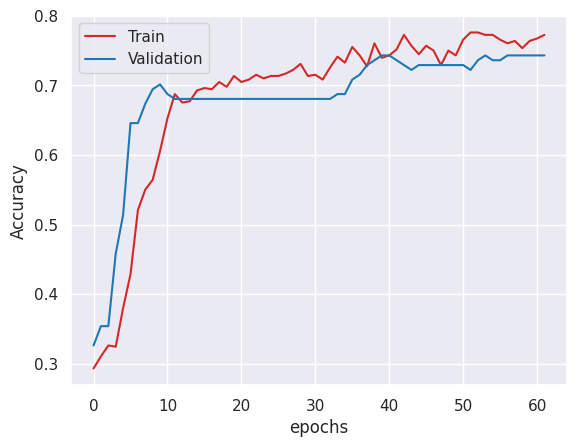

In [14]:
plt.plot(history.history['accuracy'], label='Train', color='tab:red')
plt.plot(history.history['val_accuracy'], label='Validation', color='tab:blue')
plt.xlabel('epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

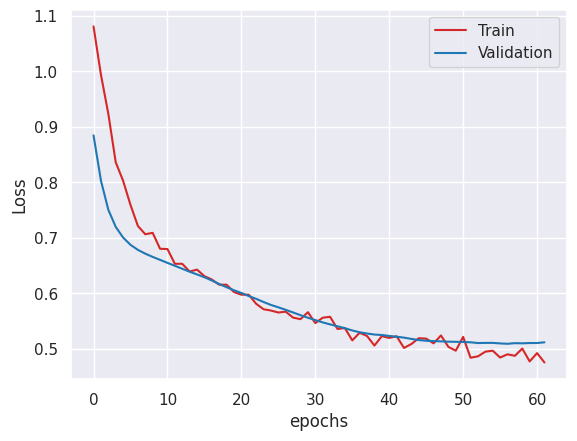

In [15]:
plt.plot(history.history['loss'], label='Train', color='tab:red')
plt.plot(history.history['val_loss'], label='Validation', color='tab:blue')
plt.xlabel('epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()